# Base Model / Null Hypothesis

This notebook contains a very basic base model, that predicts a danger level of 2 (Moderate) for every day

In [10]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '../..'))  # parent of notebooks
if project_root not in sys.path:
    sys.path.append(project_root)

import geopandas as gpd
import pandas as pd
import numpy as np
from src.util.model import eval_model, prep_data

In [5]:
dff0 = pd.read_csv("../../data/training_combined/training_combined_5.csv")
dff0['date'] = pd.to_datetime(dff0['date'])
dff0 = dff0[dff0['slope_angle'] > 0] # Removing flat slopes increases accuracy by about 6 percent

dff0 = pd.get_dummies(dff0,columns=['elevation_band','zone_name'])

danger_levels = pd.read_csv("../../../data/FAC/FAC_Danger_rating_zone_elv.csv")
danger_levels['date'] = pd.to_datetime(danger_levels['date'])

coords_geodf = gpd.read_file("../../../data/FAC/zones/grid_coords_subset.geojson")

exclude_cols = ['date','id_x','slope_azi', 'danger_level','altitude','slope_angle','lat', 'lon', 'geometry','danger_level.1'] #'elevation_band','zone_name']

In [8]:
seasons = [
    (2021, 2022),
    (2022, 2023),
    (2023, 2024),
    (2024, 2025),
]

def season_mask(df, start_year, end_year):
    start = pd.Timestamp(year=start_year, month=10, day=1)
    end = pd.Timestamp(year=end_year, month=5, day=1)
    return (df["date"] >= start) & (df["date"] <= end)

# Build X and y once
X = dff0.loc[:, ~dff0.columns.isin(exclude_cols)].copy()
y_raw = dff0["danger_level"].copy()

X = X.reset_index(drop=True)
y = y_raw.reset_index(drop=True)
df = dff0.reset_index(drop=True)

# Precompute season indices
season_indices = {}
for season in seasons:
    mask = season_mask(df, season[0], season[1])
    season_indices[season] = np.where(mask)[0]

# Build LOSO splits
cv_splits = []
for held_season in seasons:
    test_idx = season_indices[held_season]
    train_idx = np.concatenate(
        [season_indices[s] for s in seasons if s != held_season]
    )
    cv_splits.append((train_idx, test_idx))

In [9]:
trainingScores = []
testingScores = []

for fold_num, (train_idx, test_idx) in enumerate(cv_splits, start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_train = X_train.fillna(0)
    X_test = X_test.fillna(0)

    train_metrics = eval_model(y_train, pd.Series(data=[2] * y_train.shape[0]))

    test_metrics = eval_model(y_test, pd.Series(data=[2] * y_test.shape[0]))

    trainingScores.append(train_metrics)
    testingScores.append(test_metrics)

for ta in trainingScores:
    print(f"{ta},")

for ta in testingScores:
    print(f"{ta},")

Accuracy 0.45
Balanced Accuracy 0.25
MAE: 0.5777348155308523
Accuracy 0.44
Balanced Accuracy 0.25
MAE: 0.5803571428571429
Accuracy 0.43
Balanced Accuracy 0.25
MAE: 0.5994927180494191
Accuracy 0.51
Balanced Accuracy 0.25
MAE: 0.517282196969697
Accuracy 0.46
Balanced Accuracy 0.25
MAE: 0.5668599967778315
Accuracy 0.43
Balanced Accuracy 0.25
MAE: 0.6138392857142857
Accuracy 0.46
Balanced Accuracy 0.25
MAE: 0.5696614583333334
Accuracy 0.42
Balanced Accuracy 0.25
MAE: 0.6041366041366041
{'accuracy': 0.4515063637828258, 'balanced_accuracy': 0.25, 'mae': 0.5777348155308523},
{'accuracy': 0.4282441498936344, 'balanced_accuracy': 0.25, 'mae': 0.5994927180494191},
{'accuracy': 0.4561785081359755, 'balanced_accuracy': 0.25, 'mae': 0.5668599967778315},
{'accuracy': 0.4607747395833333, 'balanced_accuracy': 0.25, 'mae': 0.5696614583333334},
{'accuracy': 0.44221230158730157, 'balanced_accuracy': 0.25, 'mae': 0.5803571428571429},
{'accuracy': 0.5099431818181818, 'balanced_accuracy': 0.25, 'mae': 0.517

Accuracy 0.54
Balanced Accuracy 0.25
MAE: 0.4654407102092581


{'accuracy': 0.5409004438807863,
 'balanced_accuracy': 0.25,
 'mae': 0.4654407102092581}

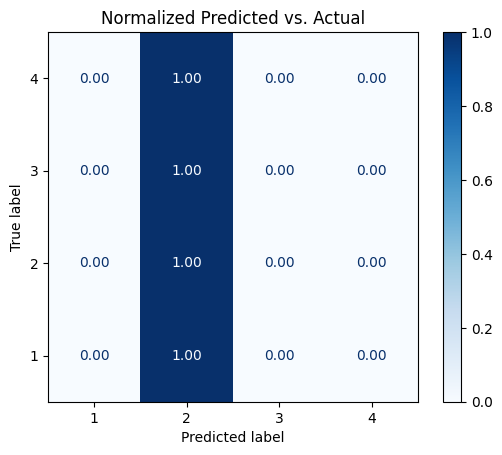

In [11]:
actual_dangers = pd.read_csv("../../data/2526_FAC/FAC_danger_levels_25.csv")

zone_map = {
    "whitefish range":"whitefish",
    "swan range":"swan",
    "flathead range & glacier np":"flathead"
}

actual_dangers['date'] = pd.to_datetime(actual_dangers['date'])
actual_dangers['zone_name'] = actual_dangers['zone_name'].apply(lambda x: zone_map[x])

curr_dff = pd.read_csv("../../data/ops25_26/new_all_predictions.csv").drop(columns=["predicted_danger"]).rename(columns={"date":"timestamp"})

val_x, val_y, val_excluded_cols = prep_data(
    curr_dff, 
    actual_dangers, 
    coords_geodf,
    replace_missing=True,
    exclude_cols=['date','id','id_x','slope_azi', 'danger_level','altitude','slope_angle','forecast_zone_id','lat', 'lon', 'geometry','HS_meas']) 

val_x = pd.get_dummies(val_x,columns=['elevation_band','zone_name'])
val_x = val_x.fillna(0)

eval_model(val_y, pd.Series(data=[2] * val_x.shape[0]), plot=True, norm=True)